In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Реализуем метод Рунге-Кутты 4-го порядка для системы Лоренца:

\begin{equation*}
\begin{cases}
\dot x = \sigma (y - x)\\
\dot y = x (\rho - z) - y\\
\dot z = x y - \beta z
\end{cases}.
\end{equation*}

In [ ]:
def f(x, sigma=10, rho=28, beta=8.0/3):
    return np.array([sigma * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - beta * x[2]])ПроGhjаваааddddddGhj

def simulate(x0, n_steps, T):
    dt = T / n_steps
    x = np.zeros((3, n_steps + 1))
    x[:, 0] = x0
    for i in range(n_steps):
        k1 = f(x[:, i])
        k2 = f(x[:, i] + k1 * dt / 2)
        k3 = f(x[:, i] + k2 * dt / 2)
        k4 = f(x[:, i] + k3 * dt)
        x[:, i+1] = x[:, i] + (k1 + 2 * k2 + 2 * k3 + k4) * dt / 6

    return x

In [ ]:
n_steps = 10000
traj_num = 2
T = 100.0
x = np.zeros((traj_num, 3, n_steps + 1))
x[0, :, :] = simulate(np.array([0.0, 1.0, 1.0]), n_steps, T)
x[1, :, :] = simulate(np.array([0.0, 1.0, 1.01]), n_steps, T)

Визуализируем решение системы.

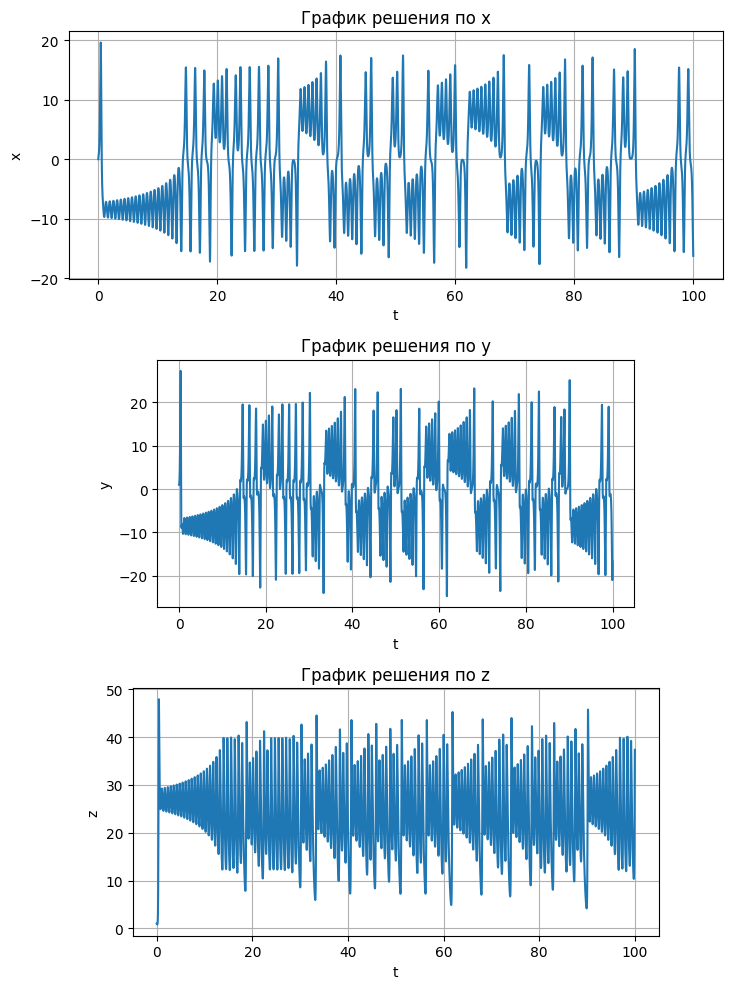

In [155]:
time_points = np.linspace(0.0, T, n_steps + 1)

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[0].set_title('График решения по x')
ax[1].set_title('График решения по y')
ax[2].set_title('График решения по z')
ax[0].plot(time_points, x[0, 0, :])
ax[1].plot(time_points, x[0, 1, :])
ax[2].plot(time_points, x[0, 2, :])
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[2].set_xlabel('t')
ax[0].set_ylabel('x')
ax[1].set_ylabel('y')
ax[2].set_ylabel('z')
fig.tight_layout()

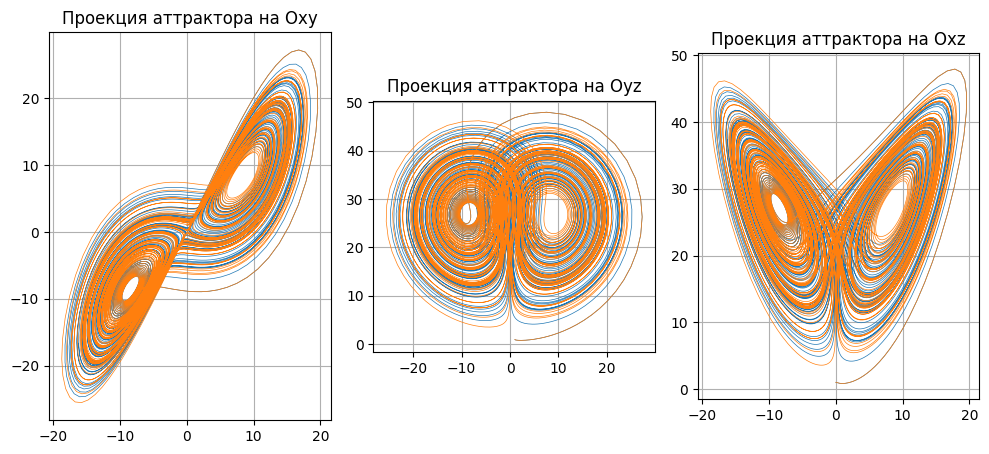

In [146]:
fig, ax = plt.subplots(1, 3, figsize=(10, 10))
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[0].set_title('Проекция аттрактора на Oxy')
ax[1].set_title('Проекция аттрактора на Oyz')
ax[2].set_title('Проекция аттрактора на Oxz')
for i in range(traj_num):
    ax[0].plot(x[i, 0, :], x[i, 1, :], lw=0.5)
    ax[1].plot(x[i, 1, :], x[i, 2, :], lw=0.5)
    ax[2].plot(x[i, 0, :], x[i, 2, :], lw=0.5)
fig.tight_layout()


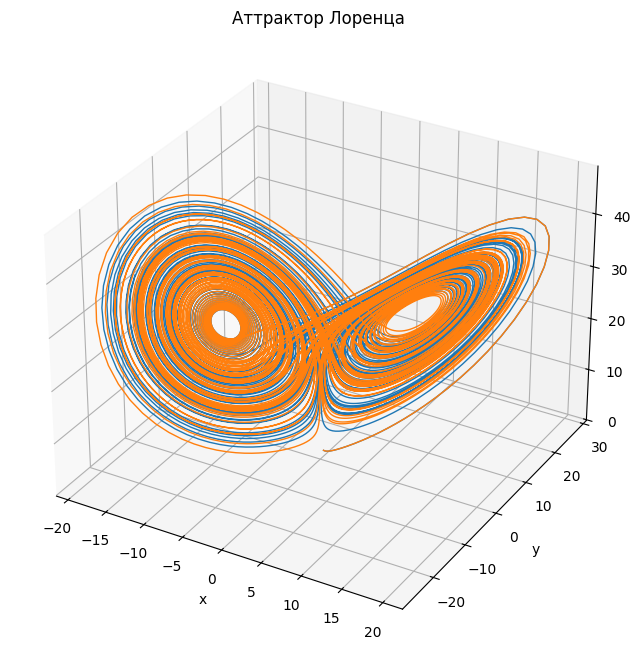

In [148]:
ax = plt.figure(figsize=(8, 8)).add_subplot(projection='3d')

for i in range(traj_num):
    ax.plot(*x[i, :, :], lw=1.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Аттрактор Лоренца")

plt.show()

Оценим чувствительность данной системы к начальным данным.

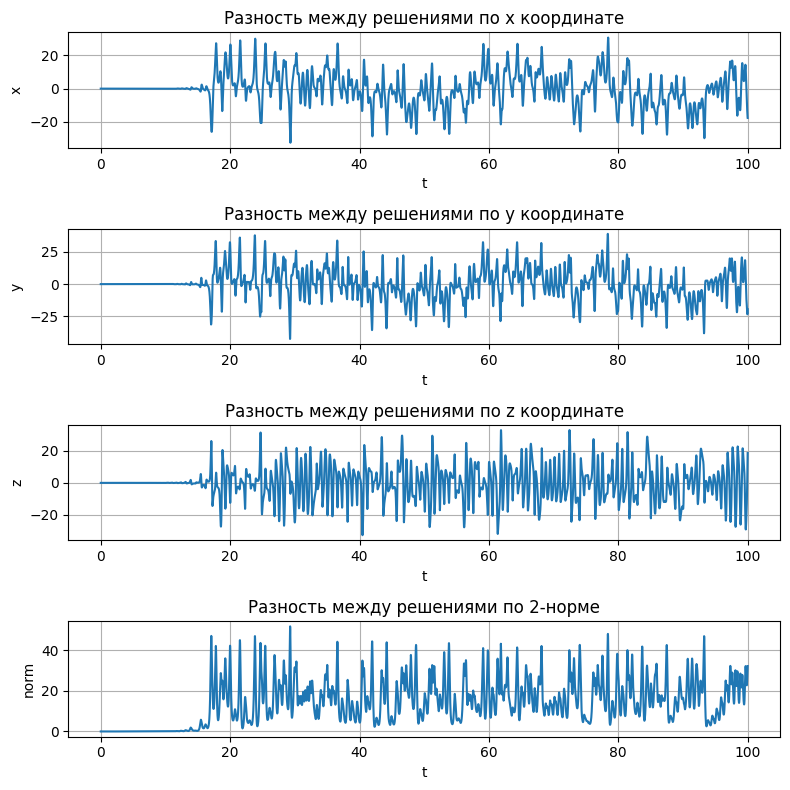

In [ ]:
norm_diff = np.linalg.norm(x[0, :, :] - x[1, :, :], axis=0)

fig, ax = plt.subplots(4, figsize=(8, 8))
ax[0].plot(time_points, x[0, 0, :] - x[1, 0, :])
ax[0].grid(True)
ax[0].set_title('Разность между решениями по x координате')
ax[0].set_xlabel('t')
ax[0].set_ylabel('x')
ax[1].plot(time_points, x[0, 1, :] - x[1, 1, :])
ax[1].grid(True)
ax[1].set_title('Разность между решениями по y координате')
ax[1].set_xlabel('t')
ax[1].set_ylabel('y')
ax[2].plot(time_points, x[0, 2, :] - x[1, 2, :])
ax[2].grid(True)
ax[2].set_title('Разность между решениями по z координате')
ax[2].set_xlabel('t')
ax[2].set_ylabel('z')
ax[3].plot(time_points, norm_diff)
ax[3].grid(True)
ax[3].set_title('Разность между решениями по 2-норме')
ax[3].set_xlabel('t')
ax[3].set_ylabel('norm')
fig.tight_layout()
plt.show()

In [145]:
print('Смещение на {} в начальных условиях дало максимальную ошибку в {} на решении.'.format(np.linalg.norm(np.array([0.0, 1.0, 1.0]) - np.array([0.0, 1.0, 1.01])),
                                                                                            np.max(norm_diff)))

Смещение на 0.010000000000000009 в начальных условиях дало максимальную ошибку в 51.62713406474892 на решении.


Для данной системы наблюдается сильная чувствительность к изменениям начальных условий.